In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        30 non-null     object
 1   Product     30 non-null     object
 2   Category    30 non-null     object
 3   Quantity    30 non-null     int64 
 4   Unit Price  30 non-null     int64 
 5   Sales       30 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 1.5+ KB


,0
Date,0
Product,0
Category,0
Quantity,0
Unit Price,0
Sales,0


In [ ]:
import pandas as pd
!pip install openpyxl
df=pd.read_excel("/content/sales_data_30_rows.xlsx")
df

,Date,Product,Category,Quantity,Unit Price,Sales
0,2025-01-01,Mouse,Electronics,5,500,2500
1,2025-01-02,Keyboard,Electronics,3,1200,3600
2,2025-01-03,Headphones,Audio,4,1500,6000
3,2025-01-04,Pendrive,Storage,10,800,8000
4,2025-01-05,SSD,Storage,2,4500,9000
5,2025-01-06,Speaker,Audio,6,2000,12000
6,2025-01-07,Webcam,Electronics,4,2500,10000
7,2025-01-08,Charger,Accessories,8,700,5600
8,2025-01-09,Power Bank,Accessories,5,1800,9000
9,2025-01-10,Monitor,Electronics,2,12000,24000


In [ ]:
df = df.dropna()
df = df.drop_duplicates()


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

In [ ]:
df.head()

,Date,Product,Category,Quantity,Unit Price,Sales,Year,Month,Day
0,2025-01-01,Mouse,Electronics,5,500,2500,2025,1,1
1,2025-01-02,Keyboard,Electronics,3,1200,3600,2025,1,2
2,2025-01-03,Headphones,Audio,4,1500,6000,2025,1,3
3,2025-01-04,Pendrive,Storage,10,800,8000,2025,1,4
4,2025-01-05,SSD,Storage,2,4500,9000,2025,1,5


In [ ]:
X = df[["Year", "Month", "Day", "Quantity", "Unit Price"]]
y = df["Sales"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (24, 5)
Testing data: (6, 5)


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(y_pred[:10])

[ 8949.50316202 10640.17661269 11245.21918159 67037.2010933
  7402.97307239 32787.24587368]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 9431.095823048094
Root Mean Squared Error (RMSE): 17589.452084242996
R² Score: -6.098787563071821


In [ ]:
result = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

result.head(10)

,Actual Sales,Predicted Sales
0,9000,8949.503162
1,12000,10640.176613
2,14000,11245.219182
3,25000,67037.201093
4,9000,7402.973072
5,24000,32787.245874


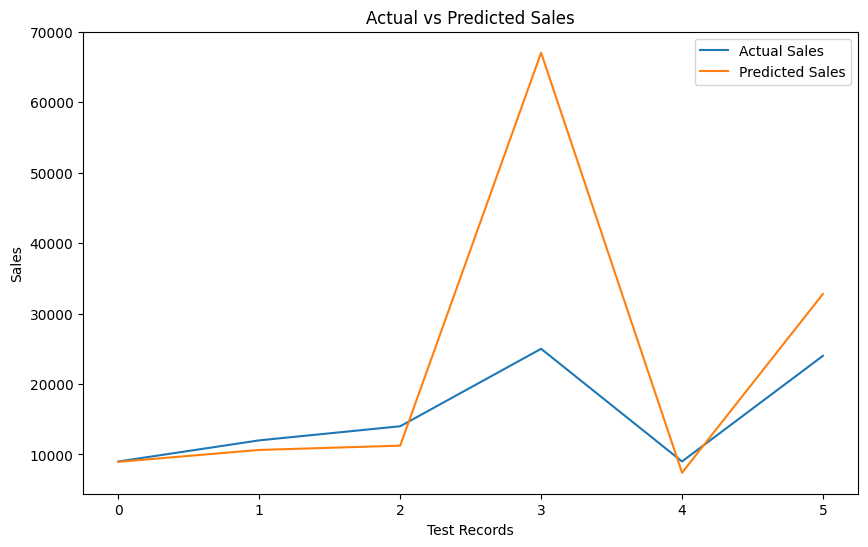

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(y_test.values, label="Actual Sales")
plt.plot(y_pred, label="Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.xlabel("Test Records")
plt.ylabel("Sales")
plt.legend()

plt.savefig("prediction_graph.png")
plt.show()

In [ ]:
result.to_csv("Predicted_Sales.csv", index=False)

In [ ]:
from google.colab import files

files.download("Predicted_Sales.csv")
files.download("prediction_graph.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>